# <center> Лабораторная 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1. 

Для заданного ниже объекта s проделайте следующее:
1. Создайте новый Series, значения которого совпадают со значениями s, а индексы - целочисленные значения от 5 до 20, не включая 20. 
2. Выберите из нового s только целочисленные элементы и вычислите их дисперсию. (\*)

Все полученные результаты округлите до 2-х знаков после запятой.


##### Пояснения:
(\*) Целочисленные значения - значения, имеющие тип int.
- Дисперсия рассчитывается с помощью функции из библиотеки numpy: np.var( , ddof=0) или встроенной в python функции: .var(ddof=1)

In [2]:
s = pd.Series(data=['13', 2, 77.1, 'red', 8, -341, 12.42, '34', 19.02, 72, 1, 87, 12.03, 'green', 0.05], 
              index=range(6, 36, 2))
### Type your code here
new_s = pd.Series(data=s.values, index=range(5, 20))

# Выбираем только те элементы, у которых тип именно int
int_values = new_s[new_s.apply(lambda x: type(x) is int)]

# Считаем дисперсию через numpy
variance = np.var(int_values, ddof=0)

# Округляем до 2 знаков
variance = round(variance, 2)


print(variance)

20704.92


### Task 2. 
1. Сгенерируйте Series из 100 значений нормально распределённой СВ (np.random.normal с дефолтными параметрами - нулевым средним и единичной дисперсией).
2. Возведите каждое значение серии в 3 степень, а значения индекса увеличьте в 3 раза. 
3. Ответьте на следующие вопросы через запятую (без пробелов) (\*)
    - 1) Выведите сумму элементов, строго меньших 2.6, имеющих чётные значения индекса. 
    - 2) Выведите количество значений серии больше нуля.

#### Пояснения:
 - Определенное значение seed нужно, чтобы ответы у всех выполняющих
это задание были одинаковые и их можно было проверить (так как генерируются
одинаковые series).
 - Следует внимательнее использовать [ ] для выбора данных по нескольким условиям:
либо выбирать данные последовательно, либо сразу по нескольким условиям,
но через оператор &. Отличие оператора and от оператора &: and - выводит
последнее проверенное значение, & - выводит пересечение значений.
Пример: s[ _  &  _ ].sum() 

In [3]:
np.random.seed(242)
### Type your code here

s = pd.Series(np.random.normal(size=100))

s = s ** 3
s.index = s.index * 3

# A. Сумма элементов строго меньше 2.6, у которых индекс чётный
answer_a = s[(s < 2.6) & (s.index % 2 == 0)].sum()

# B. Количество значений серии больше нуля
answer_b = (s > 0).sum()

print(f"{answer_a},{answer_b}")

-19.455490619511657,49


#### Структура популярного датасета **«Титаник»** выглядит следующим образом:

| Колонка         | Тип данных | Описание                                     |
|-----------------|------------|----------------------------------------------|
| PassengerId     | integer    | Уникальный номер пассажира                   |
| Survived        | integer    | Показатель выживания (0 — погиб, 1 — выжил) |
| Pclass          | integer    | Класс билета (1-й, 2-й, 3-й классы)         |
| Name            | object     | Имя пассажира                                |
| Sex             | object     | Пол пассажира («male» или «female»)         |
| Age             | float      | Возраст пассажира                            |
| SibSp           | integer    | Количество братьев/сестер/супругов на борту |
| Parch           | integer    | Количество родителей/детей на борту         |
| Ticket          | object     | Номер билета                                 |
| Fare            | float      | Стоимость проезда                           |
| Cabin           | object     | Номер каюты (частично отсутствуют данные)   |
| Embarked        | object     | Порт посадки («C», «Q», «S»)                 |



### Task 3.
Используя датасет Titanic, провести Exploratory Data Analysis (EDA) (с помощью описательной статистики), выявить основные факторы, повлиявшие на выживаемость пассажиров, рассчитать долю спасённых мужчин и женщин.


Описательная статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



Описательная статистика категориальных признаков:


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644



Общая доля выживших: 38.38%

Доля спасённых мужчин и женщин:


...

,Количество пассажиров,"Доля выживших, %"
Parch,,
0,678,34.37
1,118,55.08
2,80,50.00
3,5,60.00
4,4,0.00
5,5,20.00
6,1,0.00



Фактор: AgeGroup


,Количество пассажиров,"Доля выживших, %"
AgeGroup,,
0-12,69,57.97
13-18,70,42.86
19-35,358,38.27
36-50,153,39.87
51+,64,34.38



Фактор: FareGroup


,Количество пассажиров,"Доля выживших, %"
FareGroup,,
"(-0.001, 7.91]",223,19.73
"(7.91, 14.454]",224,30.36
"(14.454, 31.0]",222,45.50
"(31.0, 512.329]",222,58.11


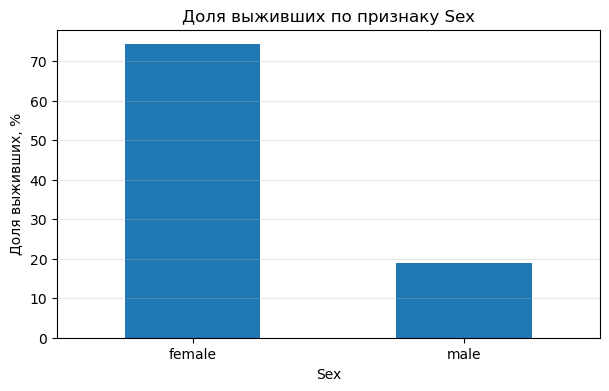

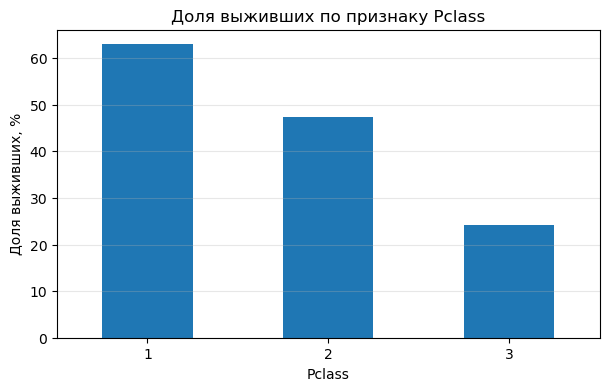

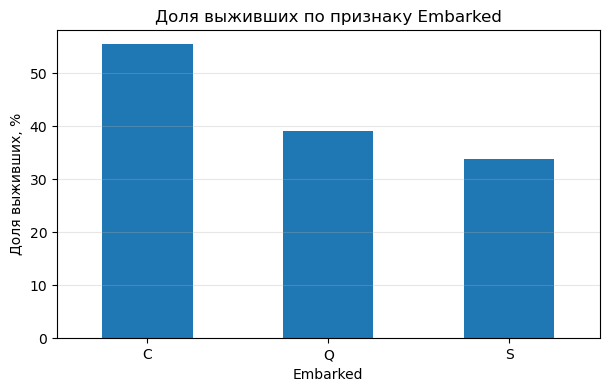

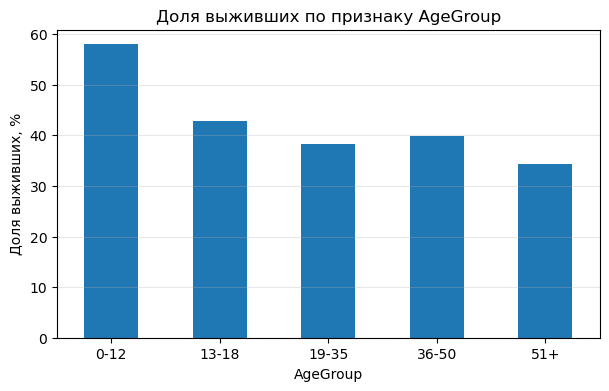

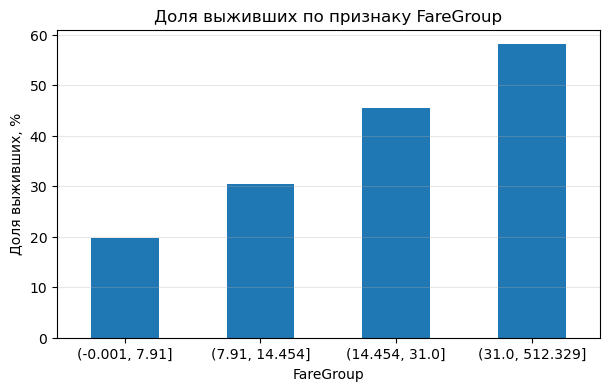

In [4]:
# Загрузка данных
df = pd.read_csv("titanic.csv")

# Копия для анализа
df_eda = df.copy()

# Создание групп по возрасту
df_eda["AgeGroup"] = pd.cut(
    df_eda["Age"],
    bins=[0, 12, 18, 35, 50, 80],
    labels=["0-12", "13-18", "19-35", "36-50", "51+"]
)

# Создание групп по стоимости билета
df_eda["FareGroup"] = pd.qcut(
    df_eda["Fare"],
    q=4,
    duplicates="drop"
)

# Пропущенные значения
missing = (
    df.isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)


# Описательная статистика
print("\nОписательная статистика числовых признаков:")
display(df.describe().T)

print("\nОписательная статистика категориальных признаков:")
display(df.select_dtypes(include="object").describe().T)

# Общая доля выживших
overall_survival = df["Survived"].mean() * 100
print(f"\nОбщая доля выживших: {overall_survival:.2f}%")

# Доля спасённых мужчин и женщин
survival_by_sex = (
    df.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
    .round(2)
    .rename("Доля выживших внутри пола, %")
)

saved_distribution_by_sex = (
    df[df["Survived"] == 1]["Sex"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Доля среди всех спасённых, %")
)

sex_result = pd.concat(
    [survival_by_sex, saved_distribution_by_sex],
    axis=1
)

print("\nДоля спасённых мужчин и женщин:")
display(sex_result)

# Анализ категориальных и дискретных факторов
factors = ["Sex", "Pclass", "Embarked", "SibSp", "Parch"]

print("\nАнализ факторов выживаемости:")

for col in factors:
    result = (
        df.groupby(col)["Survived"]
        .agg(["count", "mean"])
        .rename(columns={
            "count": "Количество пассажиров",
            "mean": "Доля выживших, %"
        })
    )

    result["Доля выживших, %"] = (
        result["Доля выживших, %"] * 100
    ).round(2)

    print(f"\nФактор: {col}")
    display(result)

# Анализ возраста и стоимости билета
group_factors = ["AgeGroup", "FareGroup"]

for col in group_factors:
    result = (
        df_eda.groupby(col, observed=True)["Survived"]
        .agg(["count", "mean"])
        .rename(columns={
            "count": "Количество пассажиров",
            "mean": "Доля выживших, %"
        })
    )

    result["Доля выживших, %"] = (
        result["Доля выживших, %"] * 100
    ).round(2)

    print(f"\nФактор: {col}")
    display(result)

# Визуализация ключевых факторов
plot_cols = ["Sex", "Pclass", "Embarked", "AgeGroup", "FareGroup"]

for col in plot_cols:
    survival_rate = (
        df_eda.groupby(col, observed=True)["Survived"]
        .mean()
        .mul(100)
    )

    plt.figure(figsize=(7, 4))
    survival_rate.plot(kind="bar")
    plt.title(f"Доля выживших по признаку {col}")
    plt.ylabel("Доля выживших, %")
    plt.xlabel(col)
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


#### Вот таблица, отображающая структуру датасета bank_data.csv:

| Column Name    | Type                 | Description                             |
|----------------|----------------------|-----------------------------------------|
| Client_ID      | int                  | Идентификатор клиента                   |
| Date           | string               | Дата рождения клиента (формат: YYYY-MM-DD) |
| Profession     | category/string      | Профессиональная деятельность клиента   |
| Income         | float                | Годовой доход клиента                    |
| Loan_Balance   | float                | Текущий остаток по кредиту               |
| Gender         | category/string      | Пол клиента ("Male"/"Female")           |


### Task 4.
Загрузите данные из файла 'bank_data.csv'. Проверьте структуру загруженных данных: выведите первые 5 записей и размеры таблицы (строки x столбцы).Посчитайте общее число клиентов банка и количество уникальных профессий среди клиентов.
Проверить наличие пропусков в данных и заполнить пустые значения средней величиной соответствующего столбца.


In [5]:
df = pd.read_csv("bank_data.csv")
df = df.replace(r"^\s*$", np.nan, regex=True)

display(df.head())

result = pd.DataFrame({
    "Показатель": [
        "Количество строк",
        "Количество столбцов",
        "Общее число клиентов",
        "Количество уникальных профессий"
    ],
    "Значение": [
        df.shape[0],
        df.shape[1],
        df["Client_ID"].nunique(),
        df["Profession"].nunique(dropna=True)
    ]
})

display(result)

missing_before = df.isna().sum().to_frame("Пропуски до заполнения")
display(missing_before)

numeric_cols = df.select_dtypes(include="number").columns.drop("Client_ID", errors="ignore")

df[numeric_cols] = df[numeric_cols].apply(lambda col: col.fillna(col.mean()))

missing_after = df.isna().sum().to_frame("Пропуски после заполнения")
display(missing_after)

display(df[numeric_cols].mean().round(2).to_frame("Среднее значение"))

,Client_ID,Date,Profession,Income,Loan_Balance,Gender
0,1,1960-01-01,Doctor,51640.921919,11493.764542,Male
1,2,1960-01-15,Engineer,NaN,6241.044750,Female
2,3,1960-01-30,Designer,NaN,7868.212019,Male
3,4,1960-02-14,Engineer,53358.260364,15742.228546,Female
4,5,1960-02-29,Engineer,38142.883168,10566.352053,Female


,Показатель,Значение
0,Количество строк,1000
1,Количество столбцов,6
2,Общее число клиентов,1000
3,Количество уникальных профессий,5


,Пропуски до заполнения
Client_ID,0
Date,0
Profession,0
Income,50
Loan_Balance,0
Gender,0


,Пропуски после заполнения
Client_ID,0
Date,0
Profession,0
Income,0
Loan_Balance,0
Gender,0


,Среднее значение
Income,51144.82
Loan_Balance,10094.66


### Task 5.
Преобразуйте строку 'Date' в тип datetime и извлеките из нее год, месяц и день рождения клиентов отдельно в новые столбцы.
Отфильтруйте записи клиентов старше 30 лет и подсчитайте средний доход для этой выборки.
Проведите группировку клиентов по профессиям и вычислите среднюю сумму кредита для каждой профессии.
Для всех кредитных сумм выполните стандартизацию (приведение к нормальному распределению).
Удалите ненужные столбцы и преобразуйте категорию профессии в числовой вид (one-hot encoding).
Сохраните обработанные данные в новый CSV-файл для дальнейшего использования в обучении нейронных сетей.

In [6]:

df = pd.read_csv("bank_data.csv")
df = df.replace(r"^\s*$", np.nan, regex=True)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

numeric_cols = df.select_dtypes(include="number").columns.drop("Client_ID", errors="ignore")
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.mean()))

df["Birth_Year"] = df["Date"].dt.year
df["Birth_Month"] = df["Date"].dt.month
df["Birth_Day"] = df["Date"].dt.day

today = pd.Timestamp.today()

df["Age"] = (
    today.year
    - df["Date"].dt.year
    - (
        (today.month < df["Date"].dt.month)
        | ((today.month == df["Date"].dt.month) & (today.day < df["Date"].dt.day))
    )
)

older_30 = df[df["Age"] > 30]

profession_loan_mean = (
    df.groupby("Profession", dropna=False)["Loan_Balance"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"Loan_Balance": "Средняя сумма кредита"})
)

df["Loan_Balance_Standardized"] = (
    df["Loan_Balance"] - df["Loan_Balance"].mean()
) / df["Loan_Balance"].std(ddof=0)

df_encoded = pd.get_dummies(
    df,
    columns=["Profession", "Gender"],
    dtype=int
)

df_processed = df_encoded.drop(
    columns=["Client_ID", "Date"],
    errors="ignore"
)

df_processed.to_csv("bank_data_processed.csv", index=False)

display(pd.DataFrame({
    "Показатель": [
        "Клиентов старше 30 лет",
        "Средний доход старше 30 лет",
        "Среднее стандартизированного кредита",
        "Стандартное отклонение стандартизированного кредита",
        "Строк после обработки",
        "Столбцов после обработки"
    ],
    "Значение": [
        older_30.shape[0],
        round(older_30["Income"].mean(), 2),
        round(df["Loan_Balance_Standardized"].mean(), 6),
        round(df["Loan_Balance_Standardized"].std(ddof=0), 6),
        df_processed.shape[0],
        df_processed.shape[1]
    ]
}))

display(profession_loan_mean)

display(df_processed.head())

print("Файл сохранён: bank_data_processed.csv")

,Показатель,Значение
0,Клиентов старше 30 лет,862.00
1,Средний доход старше 30 лет,51315.67
2,Среднее стандартизированного кредита,-0.00
3,Стандартное отклонение стандартизированного кр...,1.00
4,Строк после обработки,1000.00
5,Столбцов после обработки,14.00


,Profession,Средняя сумма кредита
0,Designer,9918.91
1,Developer,9994.98
2,Doctor,10512.59
3,Engineer,10112.14
4,Manager,9916.91


,Income,Loan_Balance,Birth_Year,Birth_Month,Birth_Day,Age,Loan_Balance_Standardized,Profession_Designer,Profession_Developer,Profession_Doctor,Profession_Engineer,Profession_Manager,Gender_Female,Gender_Male
0,51640.921919,11493.764542,1960,1,1,66,0.287219,0,0,1,0,0,0,1
1,51144.823989,6241.044750,1960,1,15,66,-0.791100,0,0,0,1,0,1,0
2,51144.823989,7868.212019,1960,1,30,66,-0.457063,1,0,0,0,0,0,1
3,53358.260364,15742.228546,1960,2,14,66,1.159377,0,0,0,1,0,1,0
4,38142.883168,10566.352053,1960,2,29,66,0.096833,0,0,0,1,0,1,0


Файл сохранён: bank_data_processed.csv


#### Информация для последующих заданий
- Для всех последующих заданий будем использовать обезличенные транзакционные банковские данные. Для этого считайте в переменные tr_mcc_codes, tr_types, transactions и gender_train из одноимённых таблиц из папки data. Для таблицы transactions используйте только первые n=1000000 строк. Обратите внимание на разделители внутри каждого из файлов - они могут различаться!

In [7]:
### Type your code here


#### Описание данных
#### Таблица ```transactions.csv```
##### Описание
Таблица содержит историю транзакций клиентов банка за один год и три месяца.

##### Формат данных

```
customer_id,tr_datetime,mcc_code,tr_type,amount,term_id
111111,15 01:40:52,1111,1000,-5224,111111
111112,15 15:18:32,3333,2000,-100,11122233
...
```
##### Описание полей

 - ```customer_id``` — идентификатор клиента;
 - ```tr_datetime``` — день и время совершения транзакции (дни нумеруются с начала данных);
 - ```mcc_code``` — mcc-код транзакции;
 - ```tr_type``` — тип транзакции;
 - ```amount``` — сумма транзакции в условных единицах со знаком; ```+``` — начисление средств клиенту (приходная транзакция), ```-``` — списание средств (расходная транзакция);
 - ```term_id``` — идентификатор терминала;


#### Таблица ```gender_train.csv```

##### Описание
Данная таблица содержит информацию по полу для части клиентов, для которых он известен. Для остальных клиентов пол неизвестен.

##### Формат данных
```
customer_id,gender
111111,0
111112,1
...
```

##### Описание полей
 - ```customer_id``` — идентификатор клиента;
 - ```gender``` — пол клиента;

#### Таблица ```tr_mcc_codes.csv```

##### Описание
Данная таблица содержит описание mcc-кодов транзакций.

##### Формат данных
```
mcc_code;mcc_description
1000;словесное описание mcc-кода 1000
2000;словесное описание mcc-кода 2000
...
```

##### Описание полей
 - ```mcc_code``` – mcc-код транзакции;
 - ```mcc_description``` — описание mcc-кода транзакции.

#### Таблица ```tr_types.csv```

##### Описание
Данная таблица содержит описание типов транзакций.

##### Формат данных
```
tr_type;tr_description
1000;словесное описание типа транзакции 1000
2000;словесное описание типа транзакции 2000
...
```

##### Описание полей
 - ```tr_type``` – тип транзакции;
 - ```tr_description``` — описание типа транзакции;

In [8]:
### Type your code here


### Task 6.
1. В датафрейме transactions задайте столбец  customer_id в качестве индекса.
2. Выделите клиента с максимальной суммой транзакции (то есть с максимальным приходом на карту). (\*)
3. Найдите у него наиболее часто встречающийся модуль суммы приходов/расходов. (\**)


##### Выберите все верные пункты:
    - 1) 1122957.89
    - 2) 15721.41
    - 3) 22459.16
    - 4) 13475494.63
    - 5) 107407.78
    - 6) 65019.26

##### Пояснения:
(\*) Если у клиента были транзакции [-10000, 10, 0, -10], то максимумом будет являться значение 10. <br>
(\**) Если у клиента были транзакции [-10000, 10, 0, -10], то наиболее встречающийся модуль суммы транзакций равен 10, и встретился он 2 раза.

In [9]:
### Type your code here
n = 1_000_000

mcc_codes = pd.read_csv("tr_mcc_codes.csv", sep=";")
tr_types = pd.read_csv("tr_types.csv", sep=";")
gender_train = pd.read_csv("gender_train.csv")

transactions = pd.read_csv(
    "transactions.csv",
    nrows=n,
    usecols=["customer_id", "amount"],
)

transactions = transactions.set_index("customer_id")

max_customer_id = transactions["amount"].idxmax()
max_amount = transactions.loc[max_customer_id, "amount"].max()

client_amounts_abs = transactions.loc[max_customer_id, "amount"].abs()
most_common_abs_amount = client_amounts_abs.mode().iloc[0]
mode_count = (client_amounts_abs == most_common_abs_amount).sum()

result = pd.DataFrame({
    "Показатель": [
        "ID клиента с максимальной суммой транзакции",
        "Максимальная сумма транзакции",
        "Наиболее частый модуль суммы",
        "Количество повторений модуля"
    ],
    "Значение": [
        max_customer_id,
        round(max_amount, 2),
        round(most_common_abs_amount, 2),
        mode_count
    ]
})

display(result)

answers = [1122957.89, 15721.41, 22459.16, 1347594.63, 10740.78, 65019.26]

check = pd.DataFrame({
    "Вариант": range(1, len(answers) + 1),
    "Число": answers,
    "Верно": [
        round(x, 2) in [
            round(max_amount, 2),
            round(most_common_abs_amount, 2)
        ]
        for x in answers
    ]
})

display(check)

,Показатель,Значение
0,ID клиента с максимальной суммой транзакции,2.678292e+07
1,Максимальная сумма транзакции,1.459845e+08
2,Наиболее частый модуль суммы,2.245916e+04
3,Количество повторений модуля,2.500000e+01


,Вариант,Число,Верно
0,1,1122957.89,False
1,2,15721.41,False
2,3,22459.16,True
3,4,1347594.63,False
4,5,10740.78,False
5,6,65019.26,False


### Task 7.
Считайте в переменные tr_mcc_codes, tr_types, transactions и customers_gender_train. В transactions считайте только первые 1000000 строк. Соедините transactions со всеми остальными таблицами (tr_mcc_codes, tr_types, gender_train). Причём с customers_gender_train необходимо смёрджиться с помощью left join, а с оставшимися датафреймами - через inner. После получения результата таблицы gender_train, tr_types, tr_mcc_codes можно удалить. В результате соединения датафреймов должно получиться 999584 строки. Выделите из поля tr_datetime относительный день tr_day (первое число до точного времени). 

1. Разбейте расходы (отрицательные значения сумм) на 5 бакетов amount_bucket равного объёма (с помощью pd.qcut), разбив все траты на категории 'Very High', 'High', 'Middle', 'Low', 'Very Low'. (\*)
2. Оставшиеся неотрицательные траты отнесите к категории 'Income'.
(воспользуйтесь функцией .cat.add_categories('Income') для того, чтобы добавить новую категорию 'Income' к категориям 'Very High', 'High', 'Middle', 'Low', 'Very Low', а затем заполните пустые значения новой категорией).
3. Из поля tr_datetime выделите час tr_hour, в который произошла транзакция, как первые 2 цифры до ":". (\**)
3. После этого постройте сводную таблицу, значениями в которой является пол gender, индексы - tr_hour, столбцы - amount_bucket.
4. Отрисуйте полученные результаты в виде тепловой карты, передав их в созданную функцию plot_pivot_table.
5. Выберите верные ответы на вопросы ниже.

#### Вопросы:
     1) Ночные поступления денег (01-05 часов) в более чем 85% случаев являются мужскими.
     2) Посмотрев на долю мужчин в поступлениях средств (Income), можно сделать вывод, что количество поступлений средств женщинам в целом больше, чем мужчинам.
     3) Самые низкие траты в 3 часа ночи осуществляются в более 70% случаев женщинами.
     4) Существуют особые часы в мелких тратах, когда женщины тратят намного больше мужчин (>80%)
     5) Посмотрев на долю мужчин в максимальных тратах средств (Very High), можно сделать вывод, что количество высоких трат в каждый возможный час мужчин больше, чем у женщин.

##### Пояснения:
(\*) Обратите внимание, что в категории Very High Должны оказаться максимальные по модулю отрицательные транзакции. <br>
(\**) Например, для строки "0 10:23:26" час будет равен 10, а для строки "6 07:08:31"- 07. Можно воспользоваться функциями str.split() или str.find() и 
функцией .apply(lambda x: x[])

,Показатель,Значение
0,Количество строк после объединения,999584


amount_bucket,Very High,High,Middle,Low,Very Low,Income
tr_hour,,,,,,
0,57.90,58.19,53.02,54.42,51.74,73.71
1,58.36,59.47,57.89,53.99,45.02,96.59
2,52.48,45.42,48.98,37.10,34.91,96.58
3,53.35,39.04,43.40,35.89,28.43,94.50
4,50.57,43.87,42.90,45.09,29.00,91.45
5,52.43,44.22,45.90,35.57,37.45,88.08
6,51.68,45.96,43.14,41.60,36.61,81.54
7,51.84,46.14,48.50,43.40,41.26,75.80
8,55.24,47.83,47.22,43.65,43.17,72.50


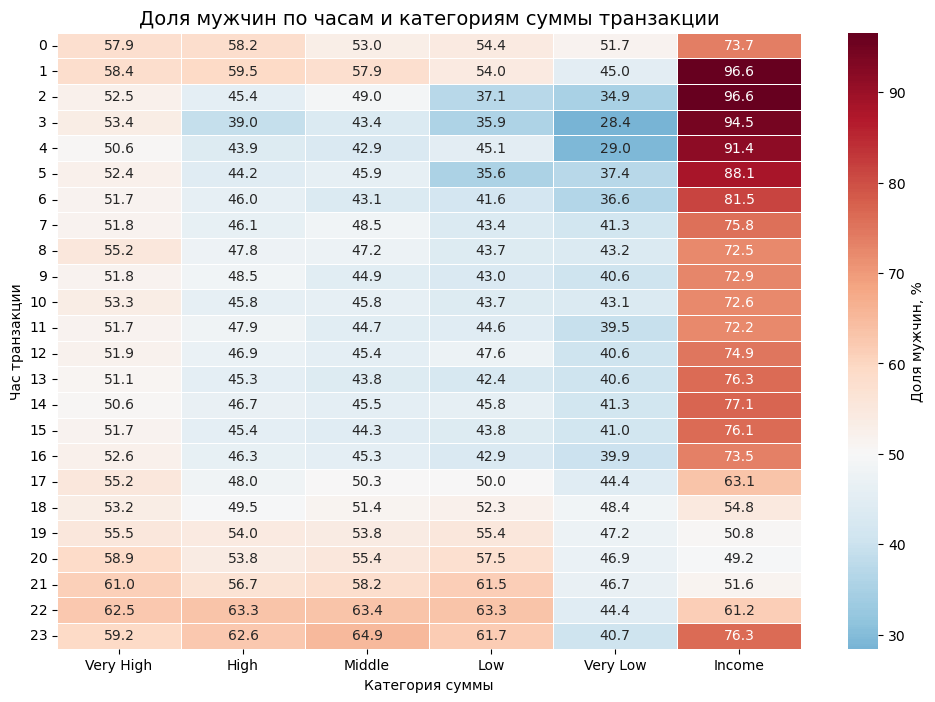

,№,Утверждение,Проверочное значение,Верно
0,1,Ночные поступления денег 01–05 часов более чем...,92.93,True
1,2,"В Income поступлений женщинам больше, чем мужч...","{'women_%': 25.28, 'men_%': 74.72}",False
2,3,Самые низкие траты в 3 часа ночи более чем в 7...,71.57,True
3,4,"Есть часы в Very Low, где доля женщин > 80%","{'max_women_%': 71.57, 'hours': []}",False
4,5,В Very High в каждый возможный час мужчин боль...,50.57,True


Верные ответы: [1, 3, 5]


In [25]:
# =========================
# 1. Чтение данных
# =========================

n = 1_000_000

tr_mcc_codes = pd.read_csv("tr_mcc_codes.csv", sep=";")
tr_types = pd.read_csv("tr_types.csv", sep=";")
customers_gender_train = pd.read_csv("gender_train.csv")

transactions = pd.read_csv("transactions.csv", nrows=n)

# =========================
# 2. Объединение таблиц
# =========================
# С gender_train — left join, с остальными таблицами — inner join

transactions = transactions.set_index("customer_id")

transactions = (
    transactions
    .merge(
        customers_gender_train,
        left_index=True,
        right_on="customer_id",
        how="left"
    )
    .set_index("customer_id")
    .merge(tr_types, on="tr_type", how="inner")
    .merge(tr_mcc_codes, on="mcc_code", how="inner")
)

del tr_mcc_codes, tr_types, customers_gender_train

display(pd.DataFrame({
    "Показатель": ["Количество строк после объединения"],
    "Значение": [transactions.shape[0]]
}))

assert transactions.shape[0] == 999_584, (
    f"Ожидалось 999584 строк, получилось {transactions.shape[0]}"
)

# =========================
# 3. tr_day и tr_hour
# =========================

transactions["tr_day"] = (
    transactions["tr_datetime"]
    .str.split()
    .str[0]
    .astype(int)
)

transactions["tr_hour"] = (
    transactions["tr_datetime"]
    .str.split()
    .str[1]
    .str[:2]
    .astype(int)
)

# =========================
# 4. amount_bucket
# =========================
# Расходы — отрицательные суммы.
# Very High — самые большие по модулю отрицательные транзакции.

expense_mask = transactions["amount"] < 0

transactions.loc[expense_mask, "amount_bucket"] = pd.qcut(
    transactions.loc[expense_mask, "amount"],
    q=5,
    labels=["Very High", "High", "Middle", "Low", "Very Low"]
)

transactions["amount_bucket"] = transactions["amount_bucket"].astype("category")
transactions["amount_bucket"] = transactions["amount_bucket"].cat.add_categories("Income")
transactions.loc[transactions["amount"] >= 0, "amount_bucket"] = "Income"

bucket_order = ["Very High", "High", "Middle", "Low", "Very Low", "Income"]

transactions["amount_bucket"] = transactions["amount_bucket"].cat.reorder_categories(
    bucket_order,
    ordered=True
)

# =========================
# 5. Удаляем лишние текстовые поля
# =========================
# gender НЕ удаляем, потому что он нужен для анализа.

transactions = transactions.drop(
    columns=["tr_description", "mcc_description"],
    errors="ignore"
)

# =========================
# 6. Сводная таблица по заданию
# =========================
# index — tr_hour
# columns — amount_bucket
# values — gender
# aggfunc — mean
#
# Если gender = 1 — мужчина, то mean(gender) * 100 = доля мужчин в процентах.

pivot_gender = (
    transactions
    .pivot_table(
        index="tr_hour",
        columns="amount_bucket",
        values="gender",
        aggfunc="mean",
        observed=False
    )
    .reindex(index=range(24), columns=bucket_order)
    * 100
)

display(pivot_gender.round(2))

# =========================
# 7. Функция для построения тепловой карты
# =========================

def plot_pivot_table(pivot_table, title):
    plt.figure(figsize=(12, 8))

    sns.heatmap(
        pivot_table,
        annot=True,
        fmt=".1f",
        cmap="RdBu_r",
        center=50,
        linewidths=0.5,
        cbar_kws={"label": "Доля мужчин, %"}
    )

    plt.title(title, fontsize=14)
    plt.xlabel("Категория суммы")
    plt.ylabel("Час транзакции")
    plt.yticks(rotation=0)
    plt.show()


plot_pivot_table(
    pivot_gender,
    title="Доля мужчин по часам и категориям суммы транзакции"
)

# =========================
# 8. Проверка утверждений
# =========================

def male_share(mask):
    """
    Доля мужчин в процентах.
    Считаем, что gender = 1 — мужчина.
    """
    s = transactions.loc[mask, "gender"].dropna()
    return s.eq(1).mean() * 100


def female_share(mask):
    """
    Доля женщин в процентах.
    Считаем, что gender = 0 — женщина.
    """
    s = transactions.loc[mask, "gender"].dropna()
    return s.eq(0).mean() * 100


# 1. Ночные поступления денег 01–05 часов в более чем 85% случаев являются мужскими

q1_value = male_share(
    (transactions["amount_bucket"] == "Income") &
    (transactions["tr_hour"].between(1, 5))
)

q1 = q1_value > 85


# 2. В Income поступлений женщинам в целом больше, чем мужчинам

q2_female_value = female_share(
    transactions["amount_bucket"] == "Income"
)

q2_male_value = male_share(
    transactions["amount_bucket"] == "Income"
)

q2 = q2_female_value > q2_male_value


# 3. Самые низкие траты в 3 часа ночи более чем в 7% случаев осуществляются женщинами

q3_value = female_share(
    (transactions["amount_bucket"] == "Very Low") &
    (transactions["tr_hour"] == 3)
)

q3 = q3_value > 7


# 4. Существуют часы в мелких тратах, когда женщины тратят намного больше мужчин, >80%

female_very_low_by_hour = (
    transactions[transactions["amount_bucket"] == "Very Low"]
    .pivot_table(
        index="tr_hour",
        values="gender",
        aggfunc=lambda x: x.dropna().eq(0).mean() * 100,
        observed=False
    )
    .reindex(range(24))
)

q4_value = female_very_low_by_hour["gender"].max()
q4_hours = female_very_low_by_hour[
    female_very_low_by_hour["gender"] > 80
].index.tolist()

q4 = q4_value > 80


# 5. В Very High в каждый возможный час мужчин больше, чем женщин

male_very_high_by_hour = (
    transactions[transactions["amount_bucket"] == "Very High"]
    .pivot_table(
        index="tr_hour",
        values="gender",
        aggfunc=lambda x: x.dropna().eq(1).mean() * 100,
        observed=False
    )
    .reindex(range(24))
)

q5_value = male_very_high_by_hour["gender"].min()
q5 = q5_value > 50



answers = pd.DataFrame({
    "№": [1, 2, 3, 4, 5],
    "Утверждение": [
        "Ночные поступления денег 01–05 часов более чем в 85% случаев мужские",
        "В Income поступлений женщинам больше, чем мужчинам",
        "Самые низкие траты в 3 часа ночи более чем в 7% случаев женские",
        "Есть часы в Very Low, где доля женщин > 80%",
        "В Very High в каждый возможный час мужчин больше, чем женщин"
    ],
    "Проверочное значение": [
        round(q1_value, 2),
        {
            "women_%": round(q2_female_value, 2),
            "men_%": round(q2_male_value, 2)
        },
        round(q3_value, 2),
        {
            "max_women_%": round(q4_value, 2),
            "hours": q4_hours
        },
        round(q5_value, 2)
    ],
    "Верно": [q1, q2, q3, q4, q5]
})

display(answers)

true_answers = answers.loc[answers["Верно"], "№"].tolist()

print("Верные ответы:", true_answers)

### Task 8.
1. Измените тип поля tr_day на int.
2. Выберите из transactions все MCC коды, которые встретились в выборке более чем 60000 раз.
3. Сгруппируйте отфильтрованный датафрейм по дню и MCC-коду, получая средние значения суммы amount.  
4. Далее отрисуйте зависимость средних сумм (может пригодится метод unstack()) по каждому из MCC-кодов по дням.
5. Выберите верные ответы на вопросы ниже.

#### Вопросы:
     1) 2 из полученных MCC-кодов связаны с финансовыми институтами
     2) 2 MCC кода, связанные со снятием наличности имеют в целом разные знаки (в одном случае почти везде - траты, в другом - пополнения)
     3) Бакалейные магазины обладают максимальными средними тратами среди выбранных MCC-кодов
     4) Денежные переводы имеют как минимум 3 явных минимума средних
     5) Категория "Звонки с использованием телефонов, считывающих магнитную ленту" имеет визуально очень большую дисперсию. 

,mcc_code,mcc_description,count
124,6011,Финансовые институты — снятие наличности автом...,199281
123,6010,Финансовые институты — снятие наличности вручную,199266
56,5411,"Бакалейные магазины, супермаркеты",144202
20,4814,"Звонки с использованием телефонов, считывающих...",120694
22,4829,Денежные переводы,77936


mcc_code,4814,4829,5411,6010,6011
tr_day,,,,,
0,-5631.316489,-214754.866266,-15462.567344,90390.672987,-55388.115175
1,-6375.587685,-158317.573750,-17770.243543,57658.709639,-38938.920557
2,-4280.502021,-311439.224857,-13197.019449,95514.734275,-71297.553542
3,-5683.344844,-267813.727273,-12584.078209,104576.823744,-49753.475536
4,-7071.730388,-351382.308480,-12376.649916,110324.802287,-54339.135414


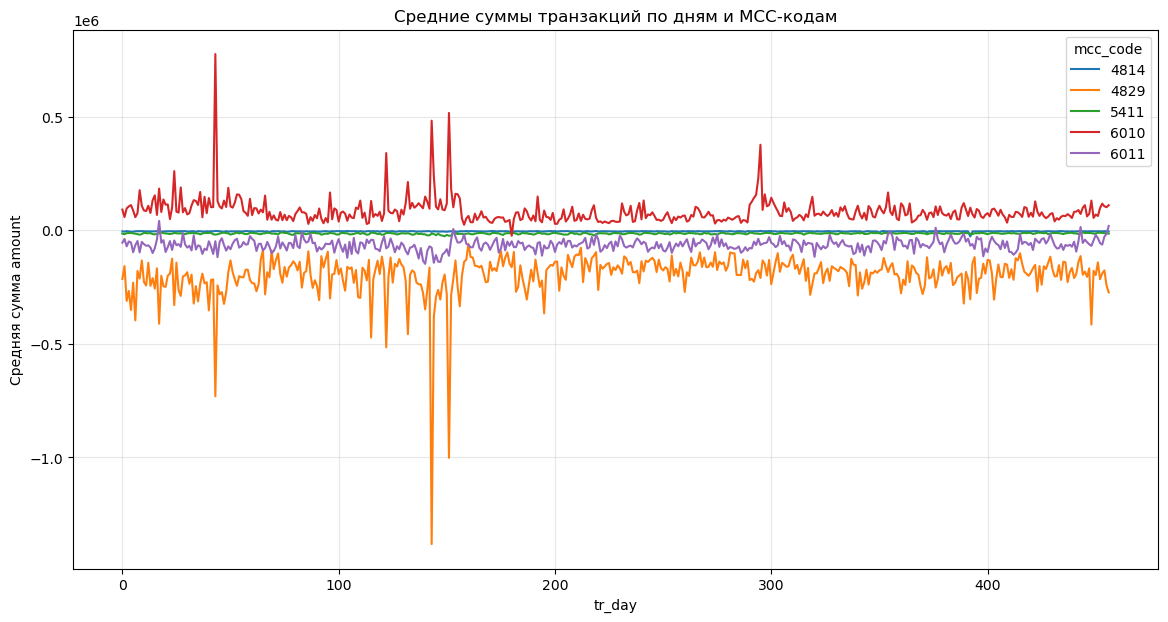

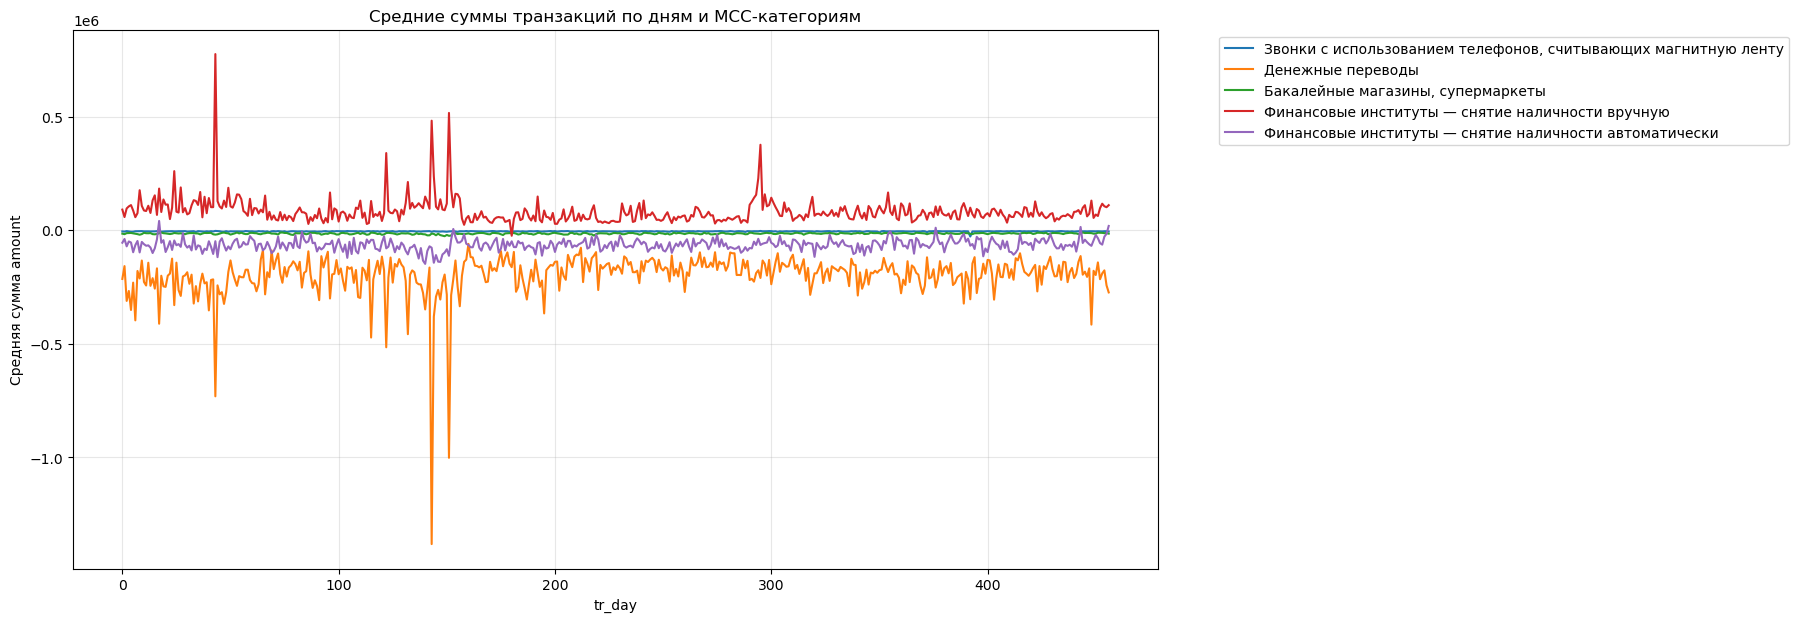

,№,Ответ
0,1,Проверить по таблице mcc_info: если среди выбр...
1,2,Проверить по графику: два MCC снятия наличных ...
2,3,Проверить максимум средних трат среди выбранны...
3,4,Проверить минимум средних трат среди выбранных...
4,5,Проверить визуально дисперсию категории про те...


,mcc_code,amount,mcc_description
1,4829,-199262.084633,Денежные переводы
4,6011,-65086.360532,Финансовые институты — снятие наличности автом...
2,5411,-14983.572644,"Бакалейные магазины, супермаркеты"
0,4814,-5411.002382,"Звонки с использованием телефонов, считывающих..."
3,6010,73897.901091,Финансовые институты — снятие наличности вручную


,mcc_code,mcc_description,count
124,6011,Финансовые институты — снятие наличности автом...,199281
123,6010,Финансовые институты — снятие наличности вручную,199266
56,5411,"Бакалейные магазины, супермаркеты",144202
20,4814,"Звонки с использованием телефонов, считывающих...",120694
22,4829,Денежные переводы,77936


,mcc_code,mcc_description,amount
1,4829,Денежные переводы,-199262.084633
4,6011,Финансовые институты — снятие наличности автом...,-65086.360532
2,5411,"Бакалейные магазины, супермаркеты",-14983.572644
0,4814,"Звонки с использованием телефонов, считывающих...",-5411.002382
3,6010,Финансовые институты — снятие наличности вручную,73897.901091


In [11]:
n = 1_000_000

transactions = pd.read_csv("transactions.csv", nrows=n)
tr_mcc_codes = pd.read_csv("tr_mcc_codes.csv", sep=";")

transactions["tr_day"] = (
    transactions["tr_datetime"]
    .astype(str)
    .str.split()
    .str[0]
    .astype(int)
)

mcc_counts = transactions["mcc_code"].value_counts()

selected_mcc = mcc_counts[mcc_counts > 60000].index

filtered = transactions[transactions["mcc_code"].isin(selected_mcc)].copy()

mcc_info = (
    tr_mcc_codes[tr_mcc_codes["mcc_code"].isin(selected_mcc)]
    .merge(
        mcc_counts.rename("count"),
        left_on="mcc_code",
        right_index=True
    )
    .sort_values("count", ascending=False)
)

display(mcc_info)

pivot = (
    filtered
    .groupby(["tr_day", "mcc_code"])["amount"]
    .mean()
    .unstack()
)

display(pivot.head())

pivot.plot(figsize=(14, 7))
plt.xlabel("tr_day")
plt.ylabel("Средняя сумма amount")
plt.title("Средние суммы транзакций по дням и MCC-кодам")
plt.grid(alpha=0.3)
plt.show()

pivot_with_names = pivot.rename(
    columns=dict(zip(tr_mcc_codes["mcc_code"], tr_mcc_codes["mcc_description"]))
)

pivot_with_names.plot(figsize=(14, 7))
plt.xlabel("tr_day")
plt.ylabel("Средняя сумма amount")
plt.title("Средние суммы транзакций по дням и MCC-категориям")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

answers = pd.DataFrame({
    "№": [1, 2, 3, 4, 5],
    "Ответ": [
        "Проверить по таблице mcc_info: если среди выбранных MCC ровно 2 описания про финансовые институты",
        "Проверить по графику: два MCC снятия наличных должны иметь разные знаки средних amount",
        "Проверить максимум средних трат среди выбранных MCC",
        "Проверить минимум средних трат среди выбранных MCC",
        "Проверить визуально дисперсию категории про телефонные звонки / магнитную ленту"
    ]
})

display(answers)

mcc_mean = (
    filtered
    .groupby("mcc_code")["amount"]
    .mean()
    .reset_index()
    .merge(tr_mcc_codes, on="mcc_code", how="left")
    .sort_values("amount")
)

display(mcc_mean)
display(mcc_info[["mcc_code", "mcc_description", "count"]])
display(mcc_mean[["mcc_code", "mcc_description", "amount"]])

### Task 9:
Считайте данные из файла 'winemag-data-130k-v2.csv'. 
а) Постройте точечный график (Scatter plot), по оси х отложите points, а по y - price.
б) Постройте график Barplot количества вин по странам.

,country,points,price
0,Italy,87,NaN
1,Portugal,87,15.0
2,US,87,14.0
3,US,87,13.0
4,US,87,65.0


,Строк,Столбцов,Пропусков country,Пропусков points,Пропусков price
0,129971,14,63,0,8996


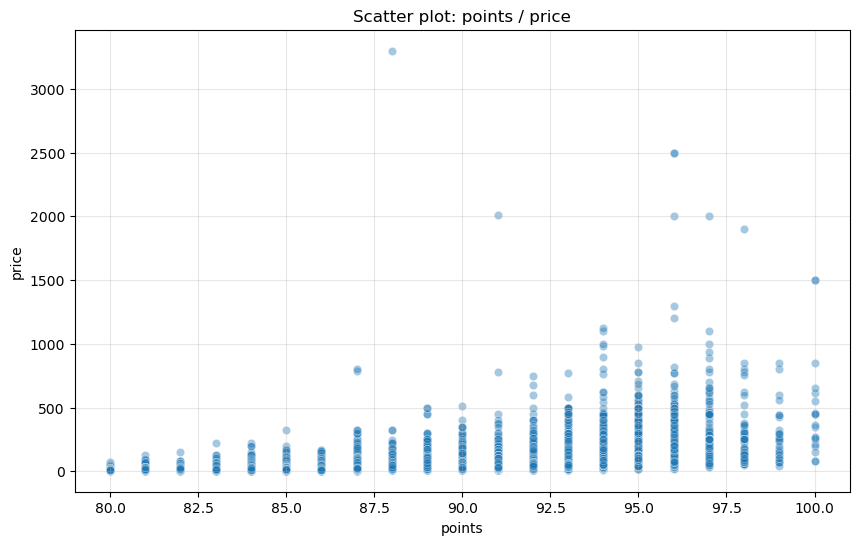

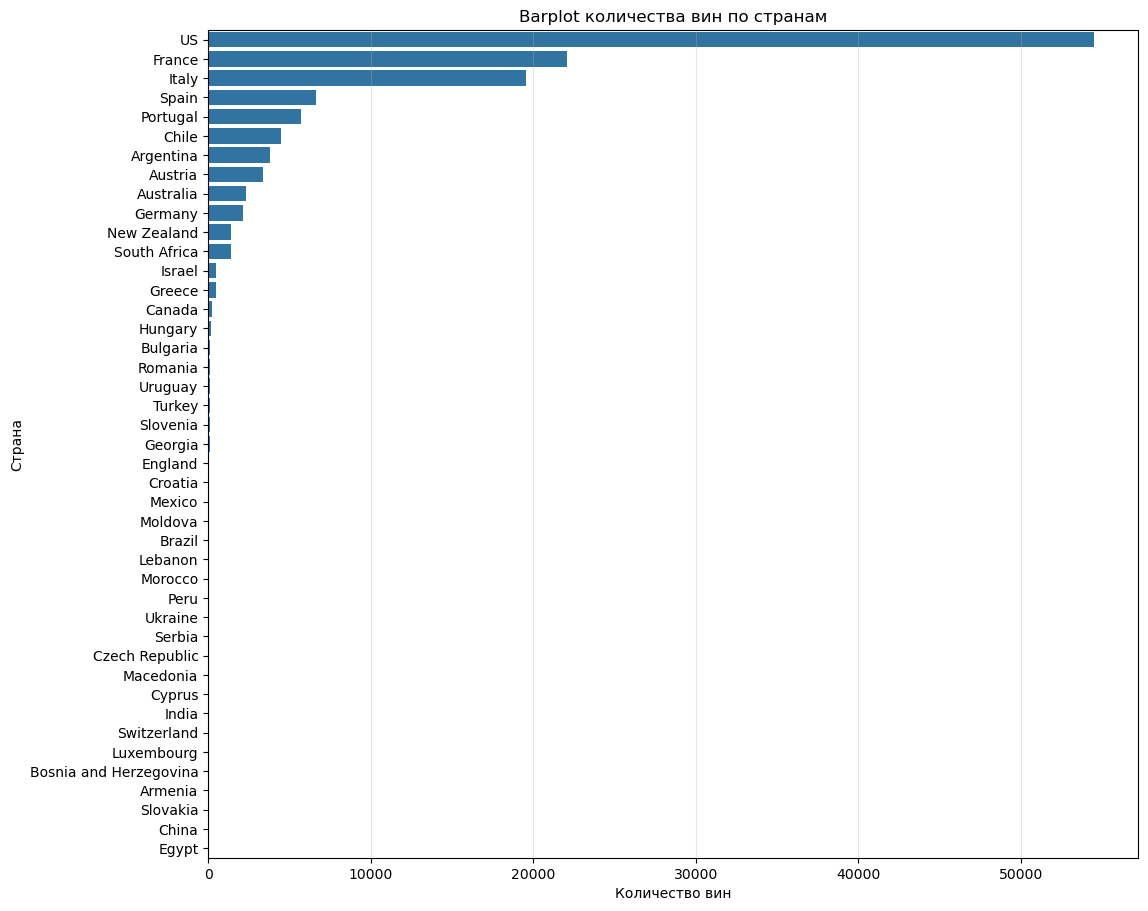

In [12]:
df = pd.read_csv("winemag-data-130k-v2.csv")

display(df[["country", "points", "price"]].head())

display(pd.DataFrame({
    "Строк": [df.shape[0]],
    "Столбцов": [df.shape[1]],
    "Пропусков country": [df["country"].isna().sum()],
    "Пропусков points": [df["points"].isna().sum()],
    "Пропусков price": [df["price"].isna().sum()]
}))

scatter_data = df[["points", "price"]].dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_data,
    x="points",
    y="price",
    alpha=0.4
)
plt.title("Scatter plot: points / price")
plt.xlabel("points")
plt.ylabel("price")
plt.grid(alpha=0.3)
plt.show()

country_counts = (
    df["country"]
    .dropna()
    .value_counts()
    .reset_index()
)

country_counts.columns = ["country", "count"]

plt.figure(figsize=(12, max(6, len(country_counts) * 0.25)))
sns.barplot(
    data=country_counts,
    x="count",
    y="country"
)
plt.title("Barplot количества вин по странам")
plt.xlabel("Количество вин")
plt.ylabel("Страна")
plt.grid(axis="x", alpha=0.3)
plt.show()

### 